In [89]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [90]:
image_path = "Images\\Test_Image.png"

In [91]:
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"

C:\Users\manue\AppData\Local\Temp\ipykernel_34412\3571225662.py:11: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(),256,[0,256], color = 'r')


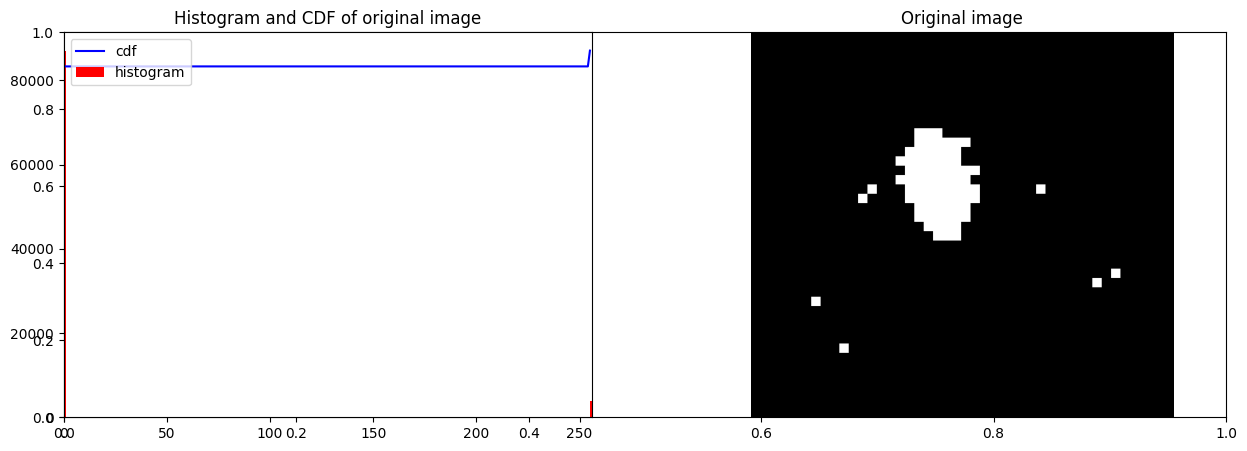

In [92]:
hist,bins = np.histogram(img.flatten(),256,[0,256])
 
cdf = hist.cumsum()
cdf_normalized = cdf * float(hist.max()) / cdf.max()
 
plt.subplots(figsize=(15, 5))

plt.subplot(1,2,1)
plt.plot(cdf_normalized, color = 'b')
plt.title('Histogram and CDF of original image')
plt.hist(img.flatten(),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')

plt.subplot(1, 2, 2)
plt.imshow(img, cmap="gray")
plt.title("Original image")
plt.axis("off")

plt.show()

In [93]:
def compute_circularity(contour):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    if perimeter == 0:
        return 0

    circularity = 4 * np.pi * area / (perimeter ** 2)
    return circularity

In [94]:
# find contours
contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print("Contours detected:", len(contours))

Contours detected: 7


In [95]:
print(type(contours))
print(contours[0].shape)

<class 'tuple'>
(4, 1, 2)


In [96]:
valid = []

for c in contours:

    area = cv2.contourArea(c)

    circ = compute_circularity(c)
    print("Area:", area, "Circularity:", circ)

    valid.append(c)

print("Valid contours:", len(valid))

Area: 36.0 Circularity: 0.7853981633974483
Area: 36.0 Circularity: 0.7853981633974483
Area: 36.0 Circularity: 0.7853981633974483
Area: 36.0 Circularity: 0.7853981633974483
Area: 36.0 Circularity: 0.7853981633974483
Area: 72.0 Circularity: 0.3502103845417971
Area: 3417.5 Circularity: 0.41109311283319444
Valid contours: 7


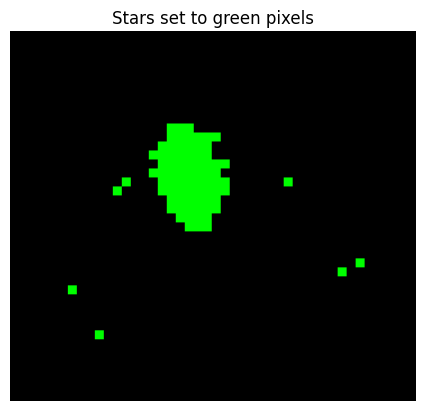

In [97]:
# fill each star contour in the mask (binary) -> similar to the mask from above
mask = np.zeros_like(img, dtype=np.uint8)
cv2.drawContours(mask, valid, -1, 255, thickness=-1)

# now check mask == 255 for all star pixels
# and set all star pixels to green in the thresholded image
overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
overlay[mask==255] = [0,255,0]

plt.imshow(overlay)
plt.axis("off")
plt.title("Stars set to green pixels")
plt.show()

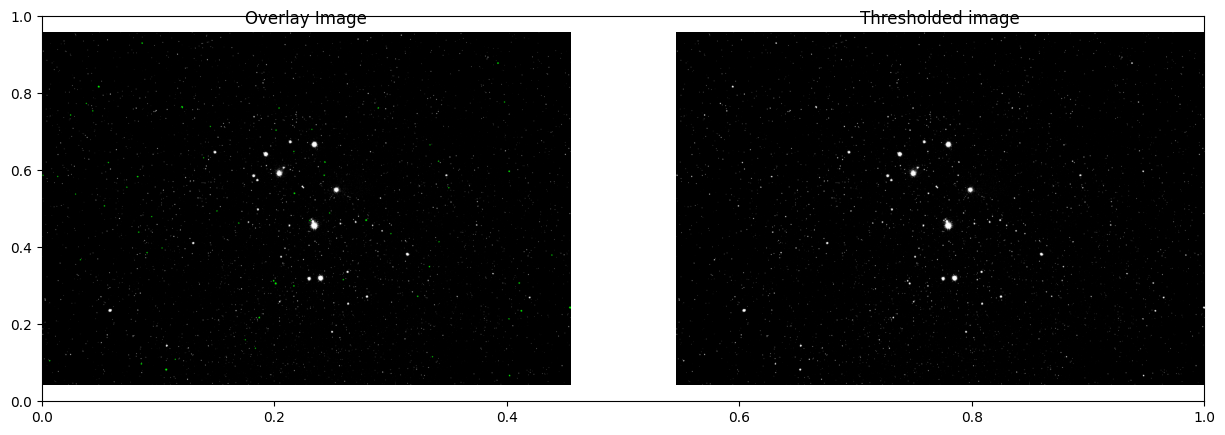

In [73]:
plt.subplots(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(overlay, cmap="gray")
plt.title("Overlay Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(thresh_binary, cmap="gray")
plt.title("Thresholded image")
plt.axis("off")

plt.show()

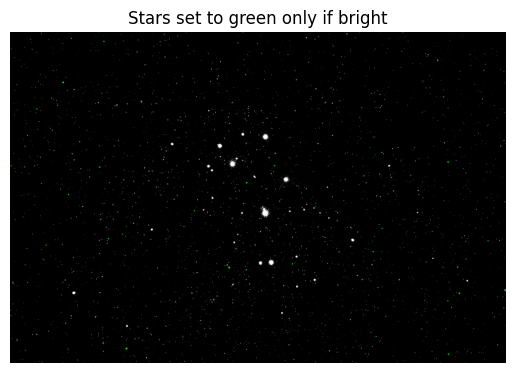

In [74]:
# 1️⃣ Create filled star mask as before
mask = np.zeros_like(thresh_binary, dtype=np.uint8)
cv2.drawContours(mask, valid, -1, 255, thickness=-1)

# 2️⃣ Convert thresholded binary image to RGB
overlay = cv2.cvtColor(thresh_binary, cv2.COLOR_GRAY2RGB)

# 3️⃣ Only replace pixels where:
#   - mask == 255 (star)
#   - overlay pixel is white (originally bright)
replace_mask = (mask==255) & (thresh_binary==255)

# 4️⃣ Set only these pixels to green
overlay[replace_mask] = [0,255,0]

# 5️⃣ Display
plt.imshow(overlay)
plt.axis("off")
plt.title("Stars set to green only if bright")
plt.show()

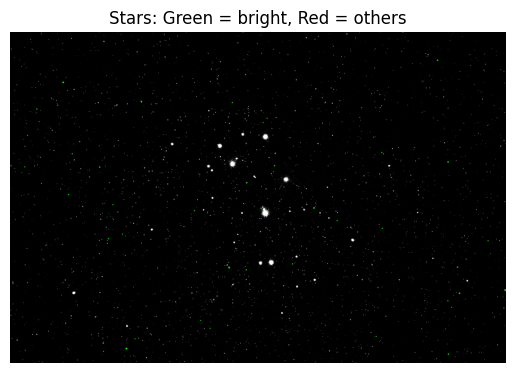

In [75]:
# 1️⃣ Filled star mask from contours
mask = np.zeros_like(thresh_binary, dtype=np.uint8)
cv2.drawContours(mask, valid, -1, 255, thickness=-1)

# 2️⃣ Convert to RGB
overlay = cv2.cvtColor(thresh_binary, cv2.COLOR_GRAY2RGB)

# 3️⃣ Green: star pixels that are bright
green_mask = (mask==255) & (thresh_binary==255)
overlay[green_mask] = [0,255,0]

# 4️⃣ Red: star pixels that are detected but not bright
red_mask = (mask==255) & (thresh_binary!=255)
overlay[red_mask] = [255,0,0]

# 5️⃣ Display
plt.imshow(overlay)
plt.axis("off")
plt.title("Stars: Green = bright, Red = others")
plt.show()

In [76]:
cv2.imwrite("overlay.png", overlay)

True